In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dtw import dtw

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



Dynamic Time Warping (DTW) is a method used to match two series by modyfing time (slowing down or speeding up selected parts of a series)

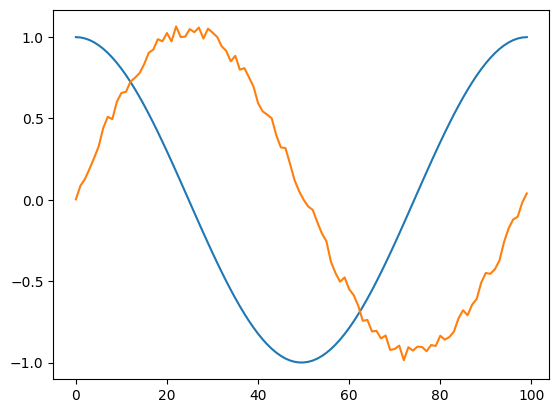

In [2]:
idx = np.linspace(0,6.28,num=100)
series_sin = np.sin(idx) + np.random.uniform(size=100)/10.0
series_cos = np.cos(idx)
plt.plot(series_cos)
plt.plot(series_sin)

<Axes: >

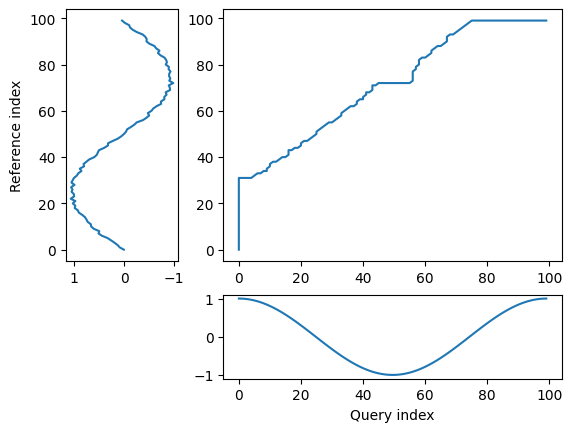

In [3]:
alignment = dtw(series_cos, series_sin, keep_internals=True)
alignment.plot(type="threeway")

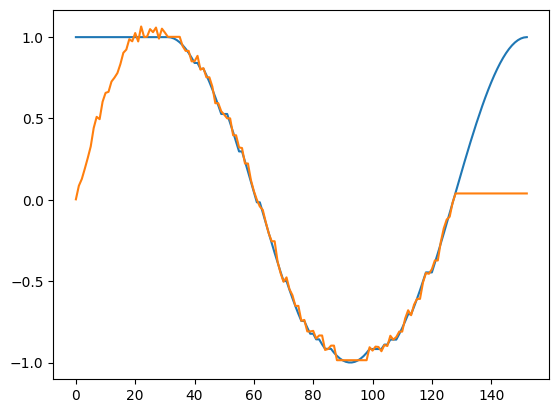

In [4]:
plt.plot(series_cos[alignment.index1])
plt.plot(series_sin[alignment.index2])

A similar concept but for text is used in the edit distance or the levenshtein distance method where two strings are being matched by either inserting, deleting, or replacing a character. If you are not familiar with the algorithm you can read https://medium.com/@ethannam/understanding-the-levenshtein-distance-equation-for-beginners-c4285a5604f0

In [5]:
def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)

    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row

    return previous_row[-1]

# Example usage:
word1 = "kitten"
word2 = "sitting"
distance = levenshtein_distance(word1, word2)
print(f"The edit distance between '{word1}' and '{word2}' is: {distance}")

word3 = "flaw"
word4 = "lawn"
distance2 = levenshtein_distance(word3, word4)
print(f"The edit distance between '{word3}' and '{word4}' is: {distance2}")

The edit distance between 'kitten' and 'sitting' is: 3
The edit distance between 'flaw' and 'lawn' is: 2


There are packages with the method implemented but as your task will be to extend this algorithm it might be easier to use a simple implementation

## Task
Create a search engine that based on a query will return closest matching texts (you can use titles of wikipedia articles you have downloaded). Can you extend the edit distance method to:
  

*   penalize less errors if two letters are close to each other on a keyboard e.g. m-n
*   prioritize matching from the begining of a word. If a query is "to" then "Tomahawk" is a better match than "Potato" since we assume that's in line with users' behaviour

Propose and implement two additional extensions, show on some examples how does your approach work. As always 144h from end of this class to send the project